# Análisis de Operaciones y Gestión de Inventario
## ¿Cómo afecta el número de habitaciones, baños y camas a la disponibilidad media de los alojamientos? ¿Difiere entre ciudades?

---

### Contenido
El análisis avanza **de lo general a lo particular**:

1. **Panorámica** del inventario y de la disponibilidad.
2. **Efecto del tamaño** (habitaciones, baños, camas) sobre la disponibilidad, a nivel global.
3. **¿Difiere entre ciudades?** — el mismo análisis abierto por ciudad.
4. **Respuesta a la pregunta de negocio**, hallazgos, limitaciones y propuestas a Dirección.

En cada bloque encontrarás dos lecturas:
- 🔧 **Lectura técnica**: qué dicen los números.
- 🏢 **Lectura de negocio (operaciones)**: qué significa para la gestión del inventario.

> **Nota sobre la métrica de disponibilidad.** Usamos `availability_365` (noches disponibles
> en los próximos 365 días) como métrica principal de disponibilidad media, porque es la más
> estable y la que mejor refleja la **capacidad estructural de inventario** a lo largo del año:
> promedia el ruido estacional que contamina las ventanas cortas. Donde aporta, se contrasta con
> las ventanas de 30/60/90 días. Conviene tener presente desde el principio un matiz que se
> desarrolla en *Limitaciones*: la elección del horizonte **no es neutral**. Como se verá en §2.1,
> la (ya de por sí débil) asociación entre tamaño y disponibilidad **solo aparece en la ventana
> anual** y es prácticamente nula a 30/60/90 días. Por eso los hallazgos deben leerse como propios
> de la **disponibilidad estructural a largo plazo**, no de la ocupación táctica de corto plazo.

> **Nota metodológica.** Las variables de tamaño son discretas/ordinales y la disponibilidad es
> asimétrica, por lo que medimos la asociación con **correlación de Spearman** (monótona, sin
> asumir normalidad ni linealidad) en lugar de Pearson. En la regresión usamos además
> **coeficientes estandarizados** para comparar el peso de cada variable, y **controlamos por
> `room_type`** para descartar que el efecto del tamaño sea un artefacto de la composición del
> inventario. Este notebook es el **análisis principal**; se acompaña de un notebook
> **complementario con Random Forest** que valida las conclusiones por una vía no lineal e
> independiente.

# 0.- Preparación: librerías y carga de datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [4]:
df = pd.read_parquet('2026_06_08_pisos_turisticos_limpio.parquet')
print(f"Alojamientos: {len(df):,}  |  Variables: {df.shape[1]}")
df[['city','room_type','bedrooms','bathrooms','beds','accommodates',
    'availability_30','availability_90','availability_365']].head()

Alojamientos: 9,650  |  Variables: 35


,city,room_type,bedrooms,bathrooms,beds,accommodates,availability_30,availability_90,availability_365
0,malaga,Private room,1.00,2.00,1.00,2,7,40,130
1,madrid,Private room,1.00,1.00,1.00,1,0,0,162
2,sevilla,Entire home/apt,2.00,1.00,2.00,4,26,31,270
3,barcelona,Private room,1.00,2.00,1.00,2,9,49,300
4,girona,Private room,2.00,1.00,5.00,5,0,49,312


In [5]:
# Variables que vamos a usar en todo el análisis
TAMANO = ['bedrooms', 'bathrooms', 'beds']      # habitaciones, baños, camas
DISPONIBILIDAD = ['availability_30', 'availability_60',
                  'availability_90', 'availability_365']
ETIQUETAS = {'bedrooms': 'Habitaciones', 'bathrooms': 'Baños', 'beds': 'Camas'}

# Comprobación de calidad mínima para el análisis
print("Nulos en variables de tamaño y disponibilidad:")
print(df[TAMANO + DISPONIBILIDAD].isna().sum())

Nulos en variables de tamaño y disponibilidad:
bedrooms            0
bathrooms           0
beds                0
availability_30     0
availability_60     0
availability_90     0
availability_365    0
dtype: int64


---
# 1.- Panorámica general

Antes de cruzar variables, entendemos **cuánto inventario hay** y **cómo se reparte la
disponibilidad**. Esta foto general es la base sobre la que interpretaremos todo lo demás.

### 1.1.- ¿Cuánta disponibilidad tiene el inventario?

,Media,Mediana,Mín,Máx,Desv.
availability_30,13.00,11.00,0.00,30.00,11.90
availability_60,28.80,29.00,0.00,60.00,23.00
availability_90,46.10,49.00,0.00,90.00,33.80
availability_365,187.60,182.00,0.00,365.00,131.00


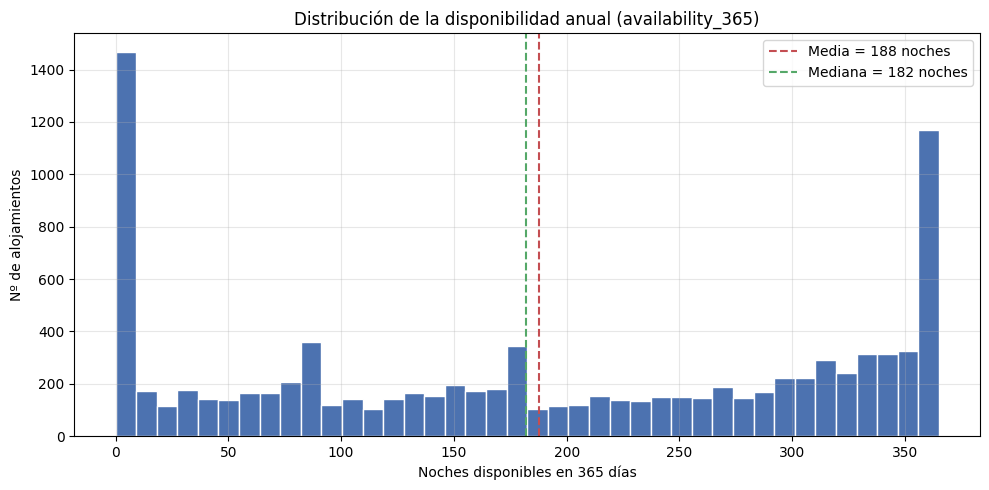

In [6]:
resumen_disp = df[DISPONIBILIDAD].describe().T[['mean','50%','min','max','std']]
resumen_disp.columns = ['Media','Mediana','Mín','Máx','Desv.']
display(resumen_disp.round(1))

fig, ax = plt.subplots()
ax.hist(df['availability_365'], bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(df['availability_365'].mean(), color='#C44E52', linestyle='--',
           label=f"Media = {df['availability_365'].mean():.0f} noches")
ax.axvline(df['availability_365'].median(), color='#55A868', linestyle='--',
           label=f"Mediana = {df['availability_365'].median():.0f} noches")
ax.set_title('Distribución de la disponibilidad anual (availability_365)')
ax.set_xlabel('Noches disponibles en 365 días'); ax.set_ylabel('Nº de alojamientos')
ax.legend(); plt.tight_layout(); plt.show()

**🔧 Lectura técnica.** La disponibilidad anual media es de unas **188 noches** (mediana 182),
con una dispersión muy alta (desv. ≈130) y un reparto casi plano entre 0 y 365: hay tanto
alojamientos casi siempre ocupados/bloqueados como otros disponibles todo el año.

**🏢 Lectura de negocio.** El inventario está, de media, **disponible aproximadamente la mitad del año**.
No existe un patrón único: conviven dos grandes grupos —pisos muy poco disponibles y pisos muy
disponibles—. Esto ya anticipa que un solo factor difícilmente explicará la disponibilidad.

### 1.2.- ¿Cómo es el inventario por tamaño?

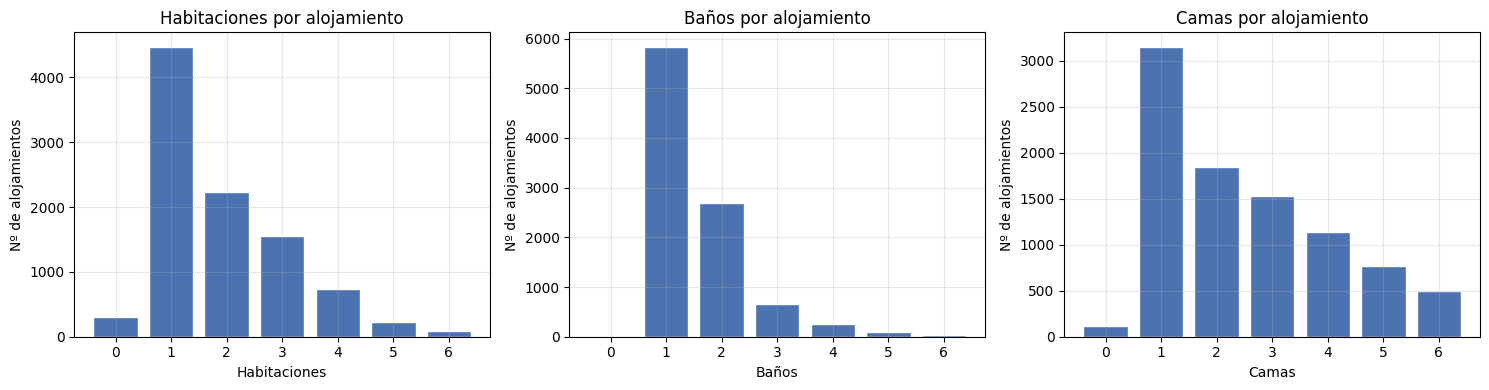

Tamaño medio del inventario:
Habitaciones   1.93
Baños          1.59
Camas          2.91
dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, TAMANO):
    vc = df[col].value_counts().sort_index()
    vc = vc[vc.index <= 6]  # recortamos cola larga para legibilidad
    ax.bar(vc.index.astype(int), vc.values, color='#4C72B0', edgecolor='white')
    ax.set_title(f'{ETIQUETAS[col]} por alojamiento')
    ax.set_xlabel(ETIQUETAS[col]); ax.set_ylabel('Nº de alojamientos')
plt.tight_layout(); plt.show()

print("Tamaño medio del inventario:")
print(df[TAMANO].mean().rename(ETIQUETAS).round(2))

**🔧 Lectura técnica.** El inventario es mayoritariamente pequeño: la moda es **1 habitación,
1 baño** y entre **1 y 2 camas**. Las medias (≈1.9 hab., ≈1.6 baños, ≈3.0 camas) confirman el sesgo
hacia alojamientos compactos.

**🏢 Lectura de negocio.** El catálogo de StaySpain está dominado por **pisos pequeños de uso
turístico estándar**. Cualquier conclusión sobre el efecto del tamaño debe leerse sabiendo que los
alojamientos grandes son minoría (menos representados estadísticamente).

### 1.3.- ¿Cuánto inventario hay en cada ciudad?

,alojamientos,disp_media,disp_mediana
city,,,
barcelona,2719,183.30,180.00
madrid,2134,165.50,146.00
mallorca,1583,213.90,220.00
girona,1485,196.60,200.00
valencia,513,170.00,159.00
malaga,504,199.60,215.00
sevilla,494,196.30,198.50
menorca,218,200.10,180.00


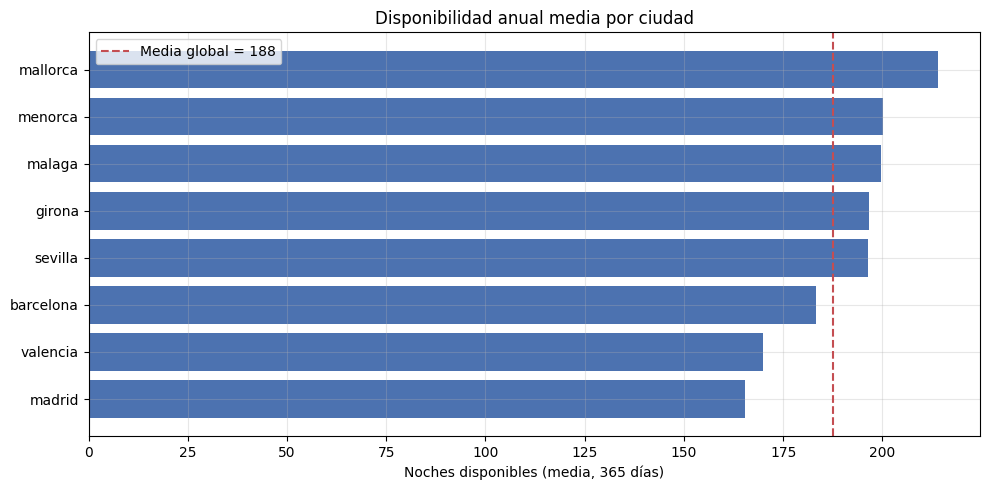

In [8]:
tabla_ciudad = (df.groupby('city')
                .agg(alojamientos=('apartment_id','count'),
                     disp_media=('availability_365','mean'),
                     disp_mediana=('availability_365','median'))
                .sort_values('alojamientos', ascending=False).round(1))
display(tabla_ciudad)

fig, ax = plt.subplots()
orden = tabla_ciudad.sort_values('disp_media', ascending=True)
ax.barh(orden.index, orden['disp_media'], color='#4C72B0')
ax.axvline(df['availability_365'].mean(), color='#C44E52', linestyle='--',
           label=f"Media global = {df['availability_365'].mean():.0f}")
ax.set_title('Disponibilidad anual media por ciudad')
ax.set_xlabel('Noches disponibles (media, 365 días)')
ax.legend(); plt.tight_layout(); plt.show()

**🔧 Lectura técnica.** Barcelona (2.719) y Madrid (2.134) concentran el grueso del inventario.
La disponibilidad media varía por ciudad: **Mallorca (≈214)** lidera con claridad, seguida de un grupo intermedio
(**Menorca ≈200, Málaga ≈200, Sevilla y Girona ≈196**), mientras
**Madrid (≈166)** y **Valencia (≈170)** quedan por debajo de la media global (≈188).

**🏢 Lectura de negocio.** Hay un **componente geográfico claro en la disponibilidad**: los destinos
de costa/vacacionales tienden a tener más noches disponibles que las grandes ciudades. Madrid es el
mercado con menos disponibilidad. Esto sugiere que la ciudad es un factor de contexto que
no podemos ignorar al analizar el efecto del tamaño.

---
# 2.- ¿Afecta el tamaño a la disponibilidad? (visión global)

Ahora respondemos al corazón de la pregunta a nivel global: relación entre
**habitaciones, baños y camas** y la **disponibilidad media**.

### 2.1.- Correlación entre tamaño y disponibilidad (Spearman)

Correlación de Spearman (tamaño vs disponibilidad):


,availability_30,availability_60,availability_90,availability_365
Habitaciones,0.04,0.03,0.01,0.10
Baños,0.04,0.03,0.01,0.06
Camas,0.07,0.05,0.04,0.13


Comprobación con Pearson (mismas magnitudes, conclusión robusta):


,availability_30,availability_60,availability_90,availability_365
Habitaciones,0.05,0.03,0.02,0.10
Baños,0.05,0.03,0.02,0.07
Camas,0.07,0.05,0.04,0.12


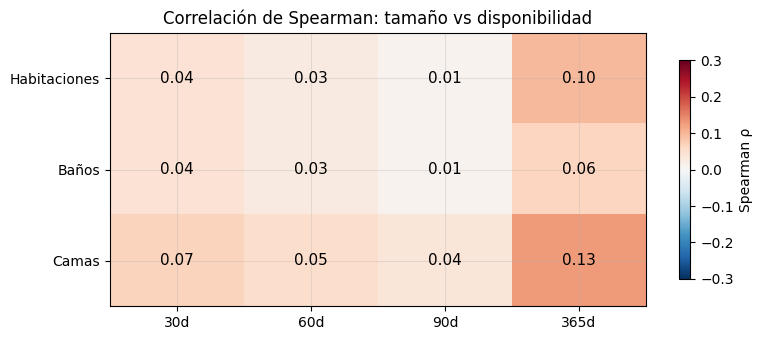

In [9]:
# Correlación de SPEARMAN (asociación monótona): adecuada porque las variables de
# tamaño son discretas/ordinales y la disponibilidad es asimétrica (no exige normalidad).
corr_s = df[TAMANO + DISPONIBILIDAD].corr(method='spearman').loc[TAMANO, DISPONIBILIDAD]
corr_show = corr_s.rename(index=ETIQUETAS)
print("Correlación de Spearman (tamaño vs disponibilidad):")
display(corr_show.round(3))

# Comprobación: Pearson da prácticamente lo mismo -> la conclusión no depende del método.
corr_p = df[TAMANO + DISPONIBILIDAD].corr(method='pearson').loc[TAMANO, DISPONIBILIDAD]
print("Comprobación con Pearson (mismas magnitudes, conclusión robusta):")
display(corr_p.rename(index=ETIQUETAS).round(3))

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(corr_s.values, cmap='RdBu_r', vmin=-0.3, vmax=0.3, aspect='auto')
ax.set_xticks(range(len(DISPONIBILIDAD)))
ax.set_xticklabels(['30d','60d','90d','365d'])
ax.set_yticks(range(len(TAMANO)))
ax.set_yticklabels([ETIQUETAS[c] for c in TAMANO])
for i in range(len(TAMANO)):
    for j in range(len(DISPONIBILIDAD)):
        ax.text(j, i, f'{corr_s.values[i,j]:.2f}', ha='center', va='center', fontsize=11)
ax.set_title('Correlación de Spearman: tamaño vs disponibilidad')
fig.colorbar(im, ax=ax, shrink=0.8, label='Spearman ρ')
plt.tight_layout(); plt.show()


**🔧 Lectura técnica.** Con **Spearman**, todas las correlaciones son **positivas pero muy débiles**.
La señal depende fuertemente del **horizonte temporal** elegido:

| Variable | 30 d | 60 d | 90 d | 365 d |
|---|---|---|---|---|
| Habitaciones | +0.04 | +0.03 | +0.01 | +0.10 |
| Baños | +0.04 | +0.03 | +0.01 | +0.06 |
| Camas | +0.07 | +0.05 | +0.04 | **+0.13** |

El patrón clave es que la asociación es **prácticamente nula en las ventanas cortas (30/60/90 días,
ρ entre +0.01 y +0.07) y solo "despierta" a 365 días** (camas +0.13, la más fuerte; baños la más floja).
Es decir, el débil efecto que el análisis encuentra existe **casi exclusivamente en el horizonte anual**.
El signo positivo es consistente en todas las ventanas, y Pearson arroja magnitudes casi idénticas: la
conclusión **no depende del método** (Spearman vs. Pearson), pero **sí depende del horizonte**. Esta
dependencia se discute en *Limitaciones*.

**🏢 Lectura de negocio.** Existe una **leve tendencia**: los alojamientos más grandes tienden a estar
algo más disponibles, pero **solo cuando se mira el año completo**. En el corto plazo (el próximo mes o
trimestre), el tamaño no se relaciona con la disponibilidad en absoluto. Operativamente: el tamaño puede
dar una pista sobre la disponibilidad *estructural* de un piso a lo largo del año, pero **no sirve para
anticipar si estará libre las próximas semanas** — para eso hace falta estudiar otras variables como la estacionalidad y el precio, que no están en este análisis.

### 2.2.- Disponibilidad media según el tamaño (efecto escalonado)

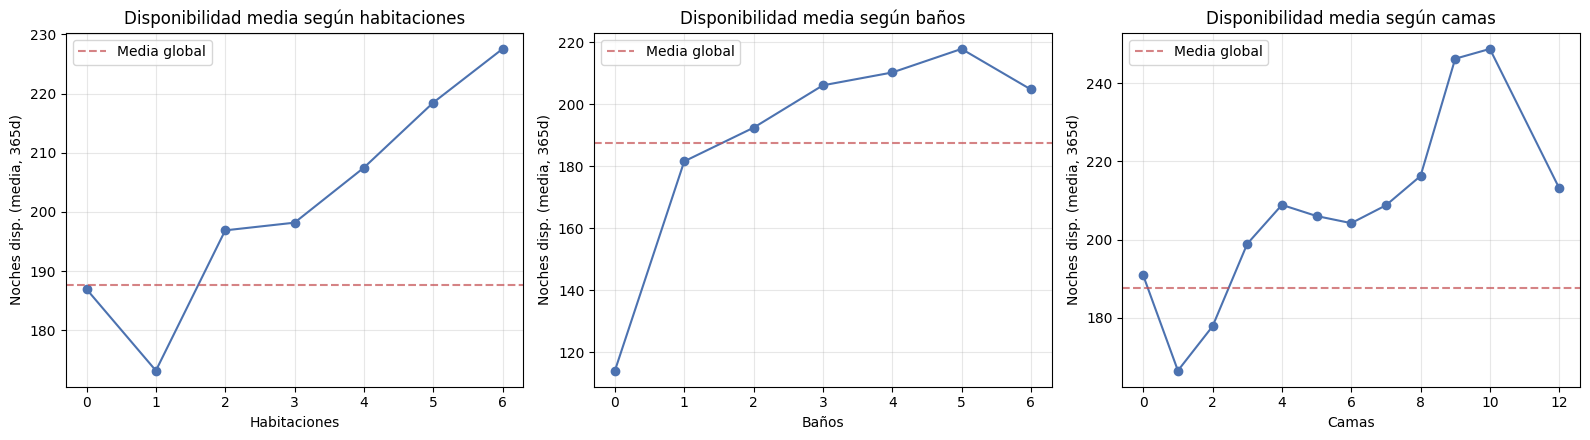

Disponibilidad anual por nº de habitaciones (grupos con muestra):


,Media,Mediana,Alojamientos
bedrooms,,,
0.00,186.90,184.00,300
1.00,173.20,163.00,4473
2.00,196.90,204.00,2227
3.00,198.20,201.00,1549
4.00,207.50,223.00,737
5.00,218.50,235.00,227
6.00,227.50,239.00,89


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, TAMANO):
    g = df.groupby(col)['availability_365'].agg(['mean','count'])
    g = g[g['count'] >= 20]            # solo grupos con muestra suficiente
    ax.plot(g.index, g['mean'], marker='o', color='#4C72B0')
    ax.axhline(df['availability_365'].mean(), color='#C44E52', linestyle='--', alpha=0.7,
               label='Media global')
    ax.set_title(f'Disponibilidad media según {ETIQUETAS[col].lower()}')
    ax.set_xlabel(ETIQUETAS[col]); ax.set_ylabel('Noches disp. (media, 365d)')
    ax.legend()
plt.tight_layout(); plt.show()

# Tabla de apoyo: bedrooms
g_bed = df.groupby('bedrooms')['availability_365'].agg(
    Media='mean', Mediana='median', Alojamientos='count').round(1)
print('Disponibilidad anual por nº de habitaciones (grupos con muestra):')
display(g_bed[g_bed['Alojamientos'] >= 20])

**🔧 Lectura técnica.** Aunque la correlación lineal es débil, al agrupar por tamaño aparece una
**tendencia monótona y ascendente** en la disponibilidad **anual** (`availability_365`): la media sube
de ~173 noches (1 habitación) a ~208–227 noches (4–6 habitaciones). El mismo patrón se ve en baños y
camas. La señal existe, pero queda diluida por la enorme dispersión dentro de cada grupo. **Importante
sobre el horizonte:** este escalonado es coherente con §2.1 —se observa porque usamos la ventana anual;
con ventanas de 30/60/90 días la escalera se aplana hasta casi desaparecer, en línea con las
correlaciones cercanas a cero en esos plazos.

**🏢 Lectura de negocio.** A lo largo del año, los **alojamientos más grandes pasan más noches
disponibles** que los pequeños: del orden de **30–50 noches más al año** entre un estudio y un piso de
4+ habitaciones. Operativamente esto encaja con que los pisos grandes son más difíciles de ocupar
(público más reducido, precio total más alto), por lo que acumulan más noches libres. Este diferencial
es una característica **estructural anual**; no implica que un piso grande vaya a estar más libre el
próximo fin de semana.

### 2.3.- ¿Cuánto del 'todo' explica el tamaño? (regresión con coeficientes estandarizados)

In [11]:
import statsmodels.api as sm

# ---------------------------------------------------------------------------
# PASO 1. Modelo en unidades ORIGINALES ("modelo").
#   y  = availability_365 (noches)
#   X  = bedrooms, bathrooms, beds (+ constante)
#   Sus coeficientes se leen como "noches de disponibilidad por unidad de la
#   variable" (p. ej. +7 noches por cada cama adicional). Útil para negocio,
#   pero NO comparables entre sí porque cada variable tiene rango distinto.
# ---------------------------------------------------------------------------
X = sm.add_constant(df[TAMANO])
y = df['availability_365']
modelo = sm.OLS(y, X).fit()

# ---------------------------------------------------------------------------
# PASO 2. Modelo ESTANDARIZADO ("modelo_z").
#   Restamos la media y dividimos por la desviación a X e y (z-score).
#   Sus coeficientes (β) están en "desviaciones estándar" y SÍ son comparables
#   entre variables: miden el peso relativo de cada dimensión de tamaño.
# ---------------------------------------------------------------------------
Xz = (df[TAMANO] - df[TAMANO].mean()) / df[TAMANO].std()
yz = (y - y.mean()) / y.std()
modelo_z = sm.OLS(yz, sm.add_constant(Xz)).fit()

# ---------------------------------------------------------------------------
# PASO 3. Tabla resumen.
#   NOTA METODOLÓGICA IMPORTANTE: estandarizar X e y es un reescalado lineal,
#   por lo que el p-value, el estadístico t y el R² son IDÉNTICOS en 'modelo' y
#   en 'modelo_z'. Lo ÚNICO que cambia es la magnitud de los coeficientes
#   (noches vs. β). Por eso:
#     - 'Coef. (noches)'        -> se toma de 'modelo'   (interpretable en negocio)
#     - 'Coef. estandarizado β' -> se toma de 'modelo_z' (comparable entre variables)
#     - 'p-value' y 'R²'        -> da igual de cuál: son los mismos en ambos.
#   Lo verificamos explícitamente más abajo.
# ---------------------------------------------------------------------------
resumen = pd.DataFrame({
    'Coef. (noches)': modelo.params,
    'Coef. estandarizado (β)': modelo_z.params,
    'p-value': modelo.pvalues
}).loc[TAMANO].rename(index=ETIQUETAS)
display(resumen.round(3))

print(f"R² del modelo (noches):        {modelo.rsquared:.4f}")
print(f"R² del modelo_z (estandarizado): {modelo_z.rsquared:.4f}")
print(f"¿p-values idénticos en ambos modelos? "
      f"{bool((modelo.pvalues[TAMANO].round(6).values == modelo_z.pvalues[TAMANO].round(6).values).all())}")
print(f"-> El tamaño explica el {modelo.rsquared*100:.1f}% de la variación de la disponibilidad anual.")

,Coef. (noches),Coef. estandarizado (β),p-value
Habitaciones,0.79,0.01,0.64
Baños,-2.86,-0.02,0.13
Camas,7.64,0.13,0.00


R² del modelo (noches):        0.0159
R² del modelo_z (estandarizado): 0.0159
¿p-values idénticos en ambos modelos? True
-> El tamaño explica el 1.6% de la variación de la disponibilidad anual.


**🔧 Lectura técnica (detallada).**

*Cómo está planteado el modelo.* Ajustamos una regresión lineal por mínimos cuadrados (OLS) que predice
la disponibilidad anual a partir de las tres variables de tamaño a la vez:
`availability_365 = β₀ + β₁·bedrooms + β₂·bathrooms + β₃·beds + error`. Estimamos **dos versiones del
mismo modelo**: `modelo` en unidades originales (coeficientes en *noches*) y `modelo_z` con todas las
variables estandarizadas (coeficientes β en *desviaciones estándar*).

*Por qué el p-value y el R² se reportan "del modelo" y no "del modelo_z".* Porque **son exactamente los
mismos en ambos**. Estandarizar es un reescalado lineal (restar media y dividir por desviación); eso
cambia la *magnitud* de los coeficientes pero **no** la significación estadística ni la bondad de ajuste
—la celda lo verifica imprimiendo que los p-values coinciden y que R²=0.016 en las dos versiones. Se usa
`modelo` para el p-value y el R² simplemente porque es el modelo "natural", y `modelo_z` solo para la
columna β (que es la única cifra que sí cambia y la única que aporta el modelo estandarizado:
comparabilidad entre variables).

*Qué dicen los resultados.* El modelo tiene un **R² ≈ 0.016**: el tamaño explica solo el **~1.6%** de la
variación de la disponibilidad anual. Al controlar las tres variables a la vez, **solo `beds` (camas) es
estadísticamente significativa** (p<0.001; coef. ≈ **+7,6 noches por cada cama adicional**). Habitaciones
(p≈0.64) y baños (p≈0.13) **no son significativas**: su efecto bruto queda absorbido por las camas, con
las que están muy correlacionadas (colinealidad). Los **coeficientes estandarizados** lo confirman en la
misma escala: camas **β≈+0.13** frente a habitaciones (β≈+0.01) y baños (β≈−0.02), ambos no
significativos. Entre las tres dimensiones de tamaño, **las camas son la única que aporta información**.

*Matiz sobre el horizonte y sobre la composición (interacciones/ratios).* El R² de 1.6% corresponde a la
ventana anual; con 30/60/90 días sería aún menor, coherente con §2.1. Además, este modelo es **puramente
aditivo y marginal**: mide cuánto cambia la disponibilidad por cada cama de más *manteniendo lo demás
constante*, pero **no modela combinaciones ni ratios** entre variables (p. ej. camas-por-habitación). Un
piso "3 hab / 1 baño" y otro "3 hab / 3 baños" entran con el mismo `bedrooms=3`; su diferencia solo se
refleja por separado en `bathrooms`, nunca como interacción. Esta limitación se documenta en
*Limitaciones*.

**🏢 Lectura de negocio (sencilla).** El tamaño físico de un alojamiento **casi no influye** en cuántas
noches estará disponible al año: de todo lo que hace que un piso esté más o menos libre, el tamaño explica
apenas un **1,6%**. El **98% restante** depende de otras cosas: temporada, precio, estancia mínima,
gestión del anfitrión, ubicación. Y si hay que quedarse con un solo dato de tamaño, el más útil es el
**número de camas** (la capacidad real de alojar gente), no las habitaciones ni los baños: cada cama de
más se asocia, de media, con unas **7–8 noches libres más al año**.

### 2.4.- Control por tipo de alojamiento (`room_type`)

Antes de pasar a las ciudades, comprobamos que el efecto del tamaño **no sea un espejismo de la
composición del inventario**: si los pisos grandes fueran sobre todo "Entire home/apt" y los pequeños
"Private room", podríamos confundir el efecto del *tipo* con el del *tamaño*. Para descartarlo,
controlamos por `room_type`.

In [12]:
# Disponibilidad media por tipo de alojamiento
disp_rt = (df.groupby('room_type')['availability_365']
           .agg(Media='mean', Mediana='median', Alojamientos='count')
           .sort_values('Alojamientos', ascending=False).round(1))
display(disp_rt)

# Correlación de Spearman tamaño<->disponibilidad DENTRO de cada tipo principal.
# (Spearman es invariante a escala, así que aquí no aplica estandarizar: trabaja
#  sobre rangos. Lo estandarizado se aplica más abajo, en la regresión.)
print("Correlación de Spearman (tamaño vs disponibilidad_365) dentro de cada room_type:")
filas = []
for rt in ['Entire home/apt', 'Private room']:
    sub = df[df['room_type'] == rt]
    fila = {'room_type': rt, 'N': len(sub)}
    for col in TAMANO:
        fila[ETIQUETAS[col]] = sub[col].corr(sub['availability_365'], method='spearman')
    filas.append(fila)
display(pd.DataFrame(filas).set_index('room_type').round(3))

# Regresión controlando el tipo: ¿sobrevive 'camas' al añadir room_type?
# COHERENCIA CON §2.3: estandarizamos las tres variables de tamaño (z-score) para
# que sus coeficientes (β) sean comparables entre sí y con los de §2.3. La variable
# 'private' es un indicador 0/1, NO se estandariza: su coeficiente ya es directamente
# interpretable como "diferencia de noches de un Private room frente a un Entire home".
d = df[df['room_type'].isin(['Entire home/apt', 'Private room'])].copy()
d['private'] = (d['room_type'] == 'Private room').astype(int)
for col in TAMANO:                      # z-score de las variables de tamaño
    d[col + '_z'] = (d[col] - d[col].mean()) / d[col].std()

Xc = sm.add_constant(d[['bedrooms_z', 'bathrooms_z', 'beds_z', 'private']])
modelo_rt = sm.OLS(d['availability_365'], Xc).fit()
res_rt = pd.DataFrame({'Coef. estandarizado (β, noches)': modelo_rt.params,
                       'p-value': modelo_rt.pvalues}).round(3)
res_rt = res_rt.rename(index={'bedrooms_z': 'Habitaciones (β)',
                              'bathrooms_z': 'Baños (β)',
                              'beds_z': 'Camas (β)',
                              'private': 'Private room (0/1)'})
display(res_rt)
print(f"R² con control por tipo: {modelo_rt.rsquared:.4f} "
      f"(vs {modelo.rsquared:.4f} sin control)")

,Media,Mediana,Alojamientos
room_type,,,
Entire home/apt,198.50,208.00,6677
Private room,161.00,127.00,2821
Hotel room,202.60,230.50,80
Shared room,205.00,285.00,72


Correlación de Spearman (tamaño vs disponibilidad_365) dentro de cada room_type:


,N,Habitaciones,Baños,Camas
room_type,,,,
Entire home/apt,6677,0.05,0.05,0.08
Private room,2821,0.02,0.00,0.06


,"Coef. estandarizado (β, noches)",p-value
const,195.29,0.00
Habitaciones (β),-2.42,0.31
Baños (β),0.25,0.90
Camas (β),13.03,0.00
Private room (0/1),-26.69,0.00


R² con control por tipo: 0.0234 (vs 0.0159 sin control)


**🔧 Lectura técnica.** *Sobre el tratamiento de las variables.* Para que esta regresión sea
comparable con la de §2.3, aquí **estandarizamos (z-score) las tres variables de tamaño**, igual que
en §2.3; lo añadido es el indicador `private` (0/1), que **no se estandariza** porque ya es directamente
interpretable (diferencia de noches de una habitación privada frente a un piso entero). Es el tratamiento
metodológicamente coherente: tamaño en β comparables, y el tipo como salto fijo en noches.

*Resultados.* El **tipo de alojamiento pesa más que cualquier variable de tamaño**: un `Private room`
está, de media, **~37 noches menos disponible** que un `Entire home/apt` (161 vs 198,5 noches), y en la
regresión el indicador de tipo es muy significativo (**≈−27 noches**, p<0.001). Aun así, **`beds` sigue
siendo la única variable de tamaño significativa** una vez incluido el tipo (β≈+0.13, p<0.001), mientras
habitaciones y baños siguen sin serlo. Dentro de cada tipo la correlación tamaño–disponibilidad sigue
siendo débil (camas ρ≈+0.08 en *Entire home/apt*, ≈+0.06 en *Private room*; y como en §2.1, estas
asociaciones se debilitan aún más en las ventanas de 30/60/90 días). Añadir el tipo sube el R² de
**1.6% a ~2.3%**: ayuda, pero el grueso de la disponibilidad sigue **sin explicarse**.

**🏢 Lectura de negocio.** El efecto del tamaño **no es un espejismo del tipo de alojamiento**: la señal
de "camas" se mantiene al separar pisos enteros de habitaciones privadas. Pero el dato accionable es otro:
**el tipo de alojamiento informa más que el tamaño** sobre la disponibilidad. Una habitación privada
tiende a estar bastante más ocupada (menos disponible) que un piso entero. Para operaciones, segmentar por
`room_type` es más útil que segmentar por número de habitaciones.

---
# 3.- ¿Difiere entre ciudades?

Repetimos el análisis del efecto del tamaño **dentro de cada ciudad**. Aquí está la parte más
accionable de la pregunta de negocio.

### 3.1.- La fuerza del efecto, ciudad a ciudad

,Alojamientos,Habitaciones,Baños,Camas
Ciudad,,,,
barcelona,2719,0.16,0.08,0.20
madrid,2134,0.05,0.03,0.10
mallorca,1583,0.02,-0.01,0.00
girona,1485,-0.04,-0.00,0.00
valencia,513,-0.02,0.05,0.03
malaga,504,-0.00,0.03,0.01
sevilla,494,0.05,-0.01,0.06
menorca,218,-0.07,-0.12,-0.03


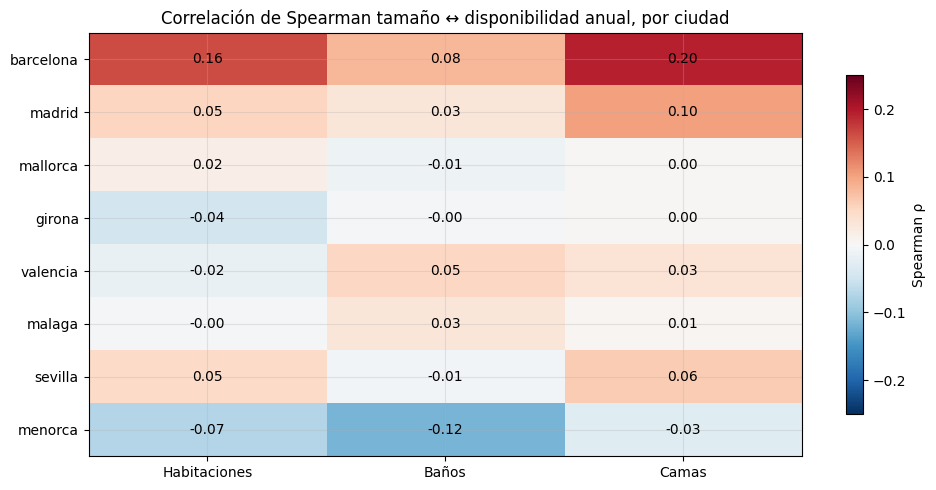

In [13]:
filas = []
for city in df['city'].value_counts().index:
    sub = df[df['city'] == city]
    fila = {'Ciudad': city, 'Alojamientos': len(sub)}
    for col in TAMANO:
        # Spearman: coherente con el resto del análisis (asociación monótona)
        fila[ETIQUETAS[col]] = sub[col].corr(sub['availability_365'], method='spearman')
    filas.append(fila)

corr_ciudad = pd.DataFrame(filas).set_index('Ciudad')
display(corr_ciudad.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
sub = corr_ciudad[[ETIQUETAS[c] for c in TAMANO]]
im = ax.imshow(sub.values, cmap='RdBu_r', vmin=-0.25, vmax=0.25, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(sub.columns)
ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub.index)
for i in range(len(sub)):
    for j in range(3):
        ax.text(j, i, f'{sub.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('Correlación de Spearman tamaño ↔ disponibilidad anual, por ciudad')
fig.colorbar(im, ax=ax, shrink=0.8, label='Spearman ρ')
plt.tight_layout(); plt.show()


**🔧 Lectura técnica.** El efecto del tamaño **no es homogéneo entre ciudades** (Spearman sobre
`availability_365`):
- **Barcelona** muestra la relación más clara y positiva (camas **ρ≈+0.20**, habitaciones **≈+0.16**).
- **Madrid** y **Sevilla** muestran efectos positivos pero débiles (camas ≈+0.06 a +0.08).
- En **Mallorca, Girona, Málaga, Valencia y Menorca** la correlación es **prácticamente nula o incluso
  negativa**: el tamaño no se relaciona con la disponibilidad, o lo hace al revés.

Como en §2.1, estas correlaciones se calculan sobre el **horizonte anual**; en ventanas de 30/60/90 días
son todavía más débiles, incluso en Barcelona. Es decir, incluso el "caso fuerte" lo es solo en clave
estructural anual.

**🏢 Lectura de negocio.** La respuesta a "¿difiere entre ciudades?" es un **sí rotundo**. En
**Barcelona** los pisos grandes sí tienden a quedar más libres a lo largo del año (mercado urbano donde
el alojamiento grande es más difícil de colocar). En los **destinos de costa/insulares** ese patrón
desaparece: allí los pisos grandes se ocupan igual o mejor que los pequeños, probablemente por la demanda
familiar y de grupos en vacaciones.

### 3.2.- El detalle: disponibilidad por tamaño y ciudad

,0 hab.,1 hab.,2 hab.,3 hab.,4 hab.,5 hab.
city,,,,,,
barcelona,204.00,164.00,210.00,231.00,217.00,245.00
girona,174.00,213.00,197.00,185.00,190.00,192.00
madrid,171.00,160.00,174.00,175.00,186.00,222.00
malaga,209.00,198.00,199.00,194.00,214.00,242.00
mallorca,201.00,211.00,212.00,209.00,220.00,224.00
menorca,277.00,206.00,218.00,185.00,181.00,225.00
sevilla,192.00,190.00,205.00,189.00,264.00,184.00
valencia,179.00,172.00,170.00,162.00,146.00,286.00


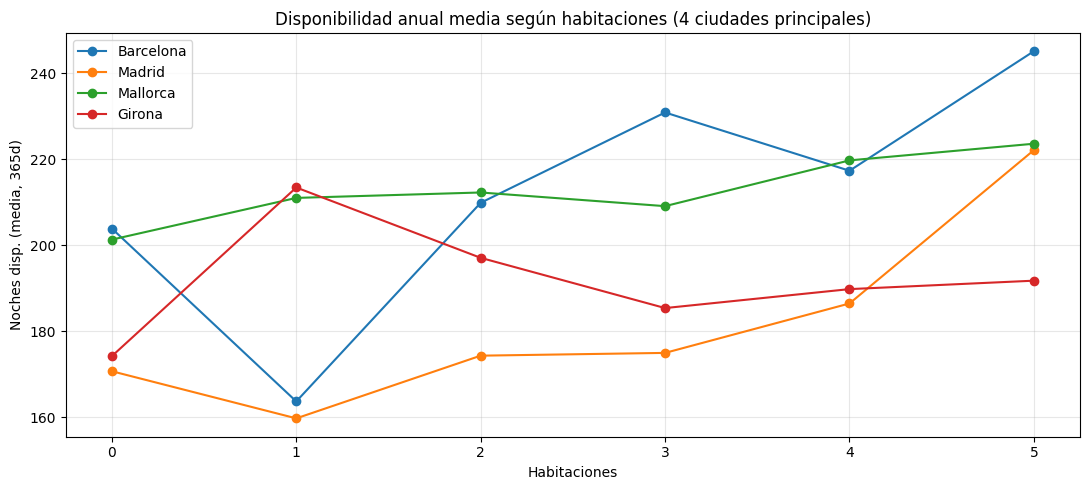

In [14]:
piv = df.pivot_table(index='city', columns='bedrooms',
                     values='availability_365', aggfunc='mean')
piv = piv[[c for c in piv.columns if c <= 5]].round(0)
piv.columns = [f'{int(c)} hab.' for c in piv.columns]
display(piv)

fig, ax = plt.subplots(figsize=(11, 5))
for city in ['barcelona','madrid','mallorca','girona']:
    g = df[df['city']==city].groupby('bedrooms')['availability_365'].mean()
    g = g[g.index <= 5]
    ax.plot(g.index, g.values, marker='o', label=city.capitalize())
ax.set_title('Disponibilidad anual media según habitaciones (4 ciudades principales)')
ax.set_xlabel('Habitaciones'); ax.set_ylabel('Noches disp. (media, 365d)')
ax.legend(); plt.tight_layout(); plt.show()

**🔧 Lectura técnica.** El gráfico muestra, para cada ciudad, la disponibilidad anual media según el
**número de habitaciones** (eje X: 1, 2, 3… habitaciones). Las trayectorias son distintas: en
**Barcelona** la disponibilidad **sube de forma sostenida** con las habitaciones (de ~164 noches con 1
hab. a ~245 con 5). En **Madrid** sube de forma muy suave. En **Mallorca** y **Girona** la curva es
**plana o irregular**: el número de habitaciones apenas mueve la disponibilidad. (El patrón es el mismo si
en lugar de habitaciones se usan camas o baños, las otras dos dimensiones de tamaño.)

**🏢 Lectura de negocio.** *Aclaración de términos.* Cuando hablamos de **"piso grande" o "piso pequeño"
nos referimos al tamaño físico del alojamiento medido por sus habitaciones, baños y camas** —las tres
variables de la pregunta de negocio—: un estudio o un piso de 1 habitación es "pequeño"; un piso de 3, 4
o más habitaciones (con sus camas y baños correspondientes) es "grande". No es una categoría oficial de la
plataforma, sino la forma de leer el eje del gráfico (a la derecha, pisos más grandes; a la izquierda, más
pequeños).

Dicho esto: la **palanca del tamaño solo es relevante en Barcelona**. Allí, un piso grande es una señal
de riesgo de baja ocupación a lo largo del año que conviene gestionar (precio, estancia mínima,
promoción). En Mallorca o Girona, en cambio, el tamaño **no sirve como criterio** para anticipar
disponibilidad: hay que mirar otros factores.

### 3.3.- Foto comparativa de la disponibilidad por ciudad

C:\Users\Ignacio\AppData\Local\Temp\ipykernel_18196\4290076699.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=[c.capitalize() for c in orden_ciudades],


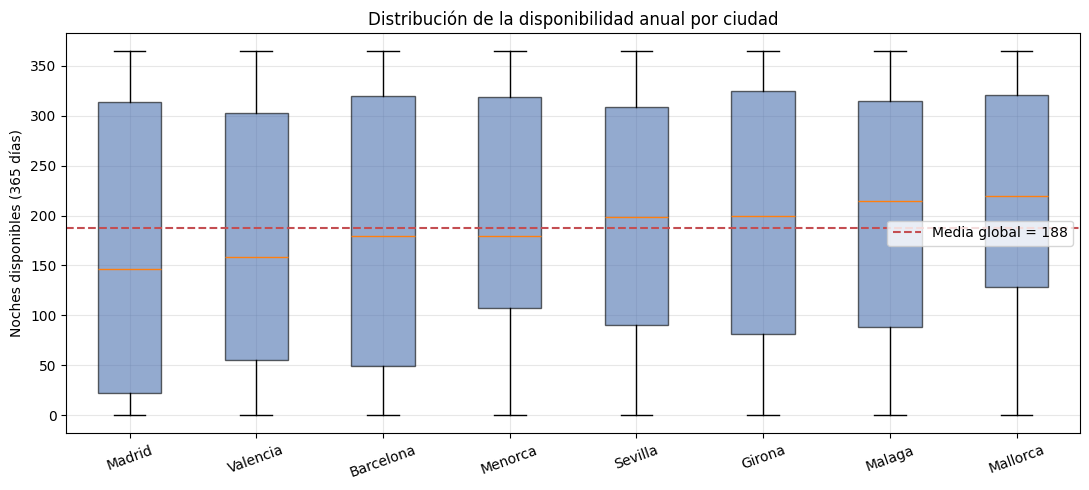

In [15]:
orden_ciudades = df.groupby('city')['availability_365'].median().sort_values().index
datos = [df.loc[df['city']==c, 'availability_365'].values for c in orden_ciudades]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(datos, labels=[c.capitalize() for c in orden_ciudades],
                patch_artist=True, showfliers=False, vert=True)
for patch in bp['boxes']:
    patch.set_facecolor('#4C72B0'); patch.set_alpha(0.6)
ax.axhline(df['availability_365'].mean(), color='#C44E52', linestyle='--',
           label=f"Media global = {df['availability_365'].mean():.0f}")
ax.set_title('Distribución de la disponibilidad anual por ciudad')
ax.set_ylabel('Noches disponibles (365 días)')
ax.legend(); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

**🔧 Lectura técnica (cómo se lee este diagrama de cajas).** Cada caja resume la distribución de la
disponibilidad anual de **todos los alojamientos de una ciudad**:
- La **línea central** de la caja es la **mediana** (el alojamiento "típico": la mitad de los pisos de esa
  ciudad están por debajo y la mitad por encima).
- Los **bordes de la caja** son el primer y el tercer cuartil (Q1 y Q3): dentro de la caja está el **50%
  central** de los alojamientos. La **altura de la caja** es el **rango intercuartílico (IQR)** y mide la
  **dispersión**: cuanto más alta, más distintos son los pisos entre sí dentro de esa ciudad.
- Los **"bigotes"** se extienden hasta los valores más extremos no atípicos.
- La **línea roja discontinua** es la media global (~188 noches), de referencia.

*Lo que se observa:* **Madrid** tiene la **mediana más baja** (≈146 noches) y **Mallorca y Málaga las más
altas** (≈215–220). En todas las ciudades el IQR es **amplio**, lo que indica **mucha heterogeneidad
interna**: dentro de una misma ciudad conviven pisos casi siempre disponibles y pisos casi siempre
ocupados. (Nota: la *media* y la *mediana* por ciudad no siempre coinciden en el orden —Barcelona, por
ejemplo, tiene mediana 180 pero media 183— porque la distribución es asimétrica; el boxplot se ordena por
mediana.)

**🏢 Lectura de negocio.** La **ciudad es un factor de contexto de primer orden**: marca el "nivel base"
de disponibilidad de un alojamiento mucho más que su tamaño. Un piso en Madrid parte de una disponibilidad
típica baja; uno en Mallorca, alta. Pero la caja ancha avisa de algo igual de importante: **conocer la
ciudad no basta** para saber cómo estará un piso concreto —dentro de cada ciudad hay enorme variación—.
Conclusión operativa: la gestión de inventario debe segmentarse **primero por ciudad** (y por tipo), y solo
después afinar con otras variables; el tamaño, por sí solo, es un criterio pobre.

---
# 4.- Respuesta a la pregunta de negocio

> **Nota sobre las fuentes.** Las afirmaciones de esta sección se respaldan en los resultados de
> **este notebook principal** (citados como §1–§3). Donde se indica, se menciona que el **notebook
> complementario de 2026_06_08_Analisis_Operaciones_Complemento** llega a las **mismas conclusiones por una vía no lineal e
> independiente** (citado como *RF §x*): se usa solo como **confirmación de coincidencia de
> resultados y de la jerarquía de variables (camas por delante de habitaciones y baños)**, no como
> herramienta de predicción.

## Pregunta
> **¿Cómo afecta el número de habitaciones, baños y camas disponibles a la disponibilidad media de los
> alojamientos? ¿Difiere entre ciudades?**

## Respuesta puntual
**El tamaño del alojamiento influye poco y de forma desigual.** A nivel global, a mayor tamaño hay algo
más de disponibilidad, pero el efecto es **muy débil**: el conjunto de habitaciones, baños y camas
explica solo el **~1.6%** de la variación de la disponibilidad anual (regresión §2.3, R²=0.016). De los
tres factores, **el número de camas es el único con efecto estadísticamente significativo** (≈ **+7,6
noches disponibles por cada cama adicional**; coeficiente estandarizado β≈+0.13; §2.3), mientras que
habitaciones y baños no aportan información adicional una vez consideradas las camas. Este resultado se
mantiene al **controlar por tipo de alojamiento** (§2.4) y **coincide con el del notebook complementario
de Random Forest**, que por una vía independiente sitúa también las **camas por delante de habitaciones y
baños** en la importancia de variables (*RF §3*).

Conviene matizar el **horizonte temporal**: esta conclusión se refiere a la disponibilidad **anual**
(`availability_365`). En las ventanas cortas (30/60/90 días) la asociación tamaño–disponibilidad es
prácticamente nula (§2.1), por lo que los hallazgos describen la **disponibilidad estructural a largo
plazo**, no la ocupación táctica de las próximas semanas.

**Y sí, difiere claramente entre ciudades.** El efecto del tamaño solo es apreciable en **Barcelona**
(correlación de Spearman camas-disponibilidad +0.20, habitaciones +0.16; §3.1), donde los pisos grandes
tienden a quedar más noches libres. En **Mallorca, Girona, Málaga, Valencia y Menorca** la relación es
**prácticamente nula o negativa** (§3.1–§3.2). El análisis por ciudad del notebook complementario
**coincide**: solo en **Barcelona** el tamaño muestra una relación positiva con la disponibilidad, y es
nula o negativa en el resto (*RF §5*).

---

## Hallazgos importantes (respaldados en datos)

1. **La disponibilidad media del inventario es de ~188 noches/año** (§1.1), con enorme dispersión:
   conviven pisos casi siempre ocupados y pisos libres todo el año.

2. **El efecto del tamaño es real pero pequeño, y solo visible a horizonte anual.** La disponibilidad
   anual sube de forma escalonada con el tamaño (§2.2): un piso de 4+ habitaciones está, de media,
   **30-50 noches más disponible al año** que un estudio. Pero la correlación de Spearman global no supera
   **+0.13** (camas; §2.1) y se desvanece en las ventanas de 30/60/90 días.

3. **Las camas mandan sobre habitaciones y baños.** En la regresión conjunta solo `beds` es
   significativa (β≈+0.13; §2.3), incluso tras **controlar por tipo de alojamiento** (§2.4). El notebook
   complementario **coincide**: las camas encabezan la importancia de variables de tamaño (*RF §3*). Lo que
   importa no es el número de cuartos, sino la **capacidad de alojar personas**.

4. **El tipo de alojamiento pesa más que el tamaño.** Una habitación privada está, de media, **~37
   noches menos disponible** que un piso entero (161 vs 198,5 noches; ≈−27 noches en la regresión con
   control, p<0.001; §2.4).

5. **La ciudad pesa más que el tamaño.** La disponibilidad media varía de ~166 noches (Madrid) a ~214
   (Mallorca) según ciudad (§1.3), un rango mucho mayor que el atribuible al tamaño.

6. **Barcelona es el caso especial.** Es la única ciudad donde el tamaño es una señal útil: los pisos
   grandes quedan sistemáticamente más libres a lo largo del año (§3.2; coincide *RF §5*).

---

## Limitaciones

- **El tamaño explica muy poco (R²≈1.6%; §2.3).** La disponibilidad está gobernada por factores que **no
  están en este análisis**: estacionalidad, precio, estancia mínima, reputación/reseñas, política del
  anfitrión y regulación local. Las conclusiones describen una **tendencia, no una capacidad de
  predicción**: con el tamaño no se puede anticipar cuántas noches estará disponible un piso concreto.

- **El análisis mide el efecto *marginal* de cada dimensión de tamaño por separado, no las
  combinaciones ni los ratios entre ellas.** La regresión (§2.3) es aditiva: estima el efecto de una cama
  de más *manteniendo constantes* habitaciones y baños, pero no incluye **términos de interacción**
  (p. ej. `bedrooms × bathrooms`) ni **ratios de composición** (p. ej. camas-por-habitación, que
  distinguiría un piso de alquiler a grupos de uno de perfil familiar). Dos pisos con las
  mismas habitaciones pero distinta densidad de camas/baños entran al modelo solo por sus valores
  individuales, nunca por su combinación. El notebook complementario de Random Forest **capturaría esas
  interacciones de forma implícita** (los árboles ramifican condiciones del tipo "si hab≥3 y baños=1…"),
  y el hecho de que tampoco mejore el ajuste es **indicio indirecto** de que la composición no añade
  capacidad explicativa relevante; pero no se han modelado de forma explícita.

- **La elección del horizonte (365 días) no es neutral.** Se usa `availability_365` por ser la métrica
  más estable de capacidad estructural, pero el (débil) efecto del tamaño **se concentra en esa ventana**:
  a 30/60/90 días la asociación es prácticamente nula (§2.1). Además, `availability_365` no es "más real"
  que las ventanas cortas, solo más estable: a horizontes largos puede haber **sesgo de calendarios no
  abiertos** (noches a 8-10 meses vista que figuran como no disponibles por inercia administrativa, no por
  reserva ni bloqueo). Por tanto, los hallazgos valen para la **disponibilidad estructural a largo plazo**;
  para gestión táctica de corto plazo, las ventanas cortas serían más relevantes.

- **Inventario sesgado a pisos pequeños** (§1.2): los alojamientos grandes son minoría, por lo que sus
  medias se apoyan en muestras reducidas (especialmente 6+ habitaciones).

- **`availability_365` es una foto declarada**, no ocupación real: mide noches *ofrecidas como
  disponibles*, que pueden incluir bloqueos del anfitrión y no equivalen necesariamente a demanda no
  cubierta.

- **Correlación ≠ causalidad.** Que un piso grande en Barcelona esté más libre no implica que el tamaño
  *cause* la baja ocupación; pueden mediar precio total más alto o público objetivo más estrecho. No hay
  histórico temporal ni test A/B que permita establecer causalidad.

---

## Propuestas a la Directora

| # | Propuesta | Hallazgo que la justifica | Prioridad | Recursos necesarios |
|---|---|---|---|---|
| 1 | **Segmentar la gestión de inventario por ciudad y por tipo, no por tamaño** | Dado que la ciudad (§1.3) y el `room_type` (§2.4) explican más disponibilidad que el tamaño (§2.3), las políticas de revenue y ocupación deben definirse primero a nivel de ciudad y tipo de alojamiento. | **Alta** | Operaciones + Revenue|
| 2 | **Activar una alerta específica para pisos grandes en Barcelona** | Es el único segmento donde el tamaño anticipa más noches libres (§3.2). Propuesta: para alojamientos de 3+ habitaciones en Barcelona, revisar precio, reducir estancia mínima y reforzar promoción para rellenar las noches libres extra.. | **Media** | Operaciones + Revenue |
| 3 | **No esperar que el tamaño explique la disponibilidad** | Con R²≈1.6% (§2.3), priorizar la captura y el análisis de los factores que sí podrian ser más explicativos: **estacionalidad, precio y estancia mínima**. | **Media** | Datos + Analítica|
| 4 | **Aprovechar los destinos de costa** | En Mallorca/Málaga la disponibilidad es alta y no depende del tamaño (§3.1): hay margen para **escalar inventario grande** (familias/grupos) sin penalización esperada en ocupación. | **Media** | Comercial + Operaciones|